In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(r"C:\Users\Bhoomi\Downloads\cleaned_clinic_appointments.csv")

In [5]:
df.head()

,patient_id,patient_name,age,gender,appointment_date,booking_date,doctor,department,billing_amount,follow_up_required,currency,appointment_month,booking_to_appointment_days
0,1080,Tammy Williams,76,Female,2026-02-26,2024-12-03,Christopher Graham,Cardiology,425.80,Yes,£,2026-02,450
1,1074,Megan Strickland,69,Female,2025-05-23,2024-06-12,Brandon Lewis,Orthopedics,344.26,Yes,€,2025-05,345
2,1067,Amanda Schroeder,79,Male,2025-11-30,2024-08-05,Deanna Edwards,Neurology,203.34,Yes,€,2025-11,482
3,1072,Anthony Mcpherson,47,Female,2025-05-18,2024-09-09,Karen Parsons,General,85.76,No,Rs,2025-05,251
4,1092,Benjamin Brown,45,Female,2026-03-07,2024-08-17,Andrea Hernandez,General,84.44,Yes,$,2026-03,567


In [6]:
df.shape

(1000, 13)

In [7]:
df.columns

Index(['patient_id', 'patient_name', 'age', 'gender', 'appointment_date',
       'booking_date', 'doctor', 'department', 'billing_amount',
       'follow_up_required', 'currency', 'appointment_month',
       'booking_to_appointment_days'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   patient_id                   1000 non-null   int64  
 1   patient_name                 1000 non-null   str    
 2   age                          1000 non-null   int64  
 3   gender                       1000 non-null   str    
 4   appointment_date             1000 non-null   str    
 5   booking_date                 1000 non-null   str    
 6   doctor                       1000 non-null   str    
 7   department                   1000 non-null   str    
 8   billing_amount               1000 non-null   float64
 9   follow_up_required           1000 non-null   str    
 10  currency                     1000 non-null   str    
 11  appointment_month            1000 non-null   str    
 12  booking_to_appointment_days  1000 non-null   int64  
dtypes: float64(1), int64(3), str(9

In [9]:
df.columns

Index(['patient_id', 'patient_name', 'age', 'gender', 'appointment_date',
       'booking_date', 'doctor', 'department', 'billing_amount',
       'follow_up_required', 'currency', 'appointment_month',
       'booking_to_appointment_days'],
      dtype='str')

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.isnull().sum()

patient_id                     0
patient_name                   0
age                            0
gender                         0
appointment_date               0
booking_date                   0
doctor                         0
department                     0
billing_amount                 0
follow_up_required             0
currency                       0
appointment_month              0
booking_to_appointment_days    0
dtype: int64

In [12]:
df.describe()

,patient_id,age,billing_amount,booking_to_appointment_days
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,1050.521000,53.750000,275.803030,274.563000
std,28.888581,21.137604,126.833397,170.492327
min,1000.000000,18.000000,51.380000,2.000000
25%,1025.000000,34.000000,166.495000,130.750000
50%,1051.000000,55.000000,269.840000,258.500000
75%,1075.000000,71.000000,383.872500,395.250000
max,1100.000000,90.000000,499.750000,728.000000


In [13]:
df.dtypes

patient_id                       int64
patient_name                       str
age                              int64
gender                             str
appointment_date                   str
booking_date                       str
doctor                             str
department                         str
billing_amount                 float64
follow_up_required                 str
currency                           str
appointment_month                  str
booking_to_appointment_days      int64
dtype: object

In [14]:
department_counts = df['department'].value_counts()

department_counts

department
Neurology      273
Orthopedics    262
Cardiology     234
General        231
Name: count, dtype: int64

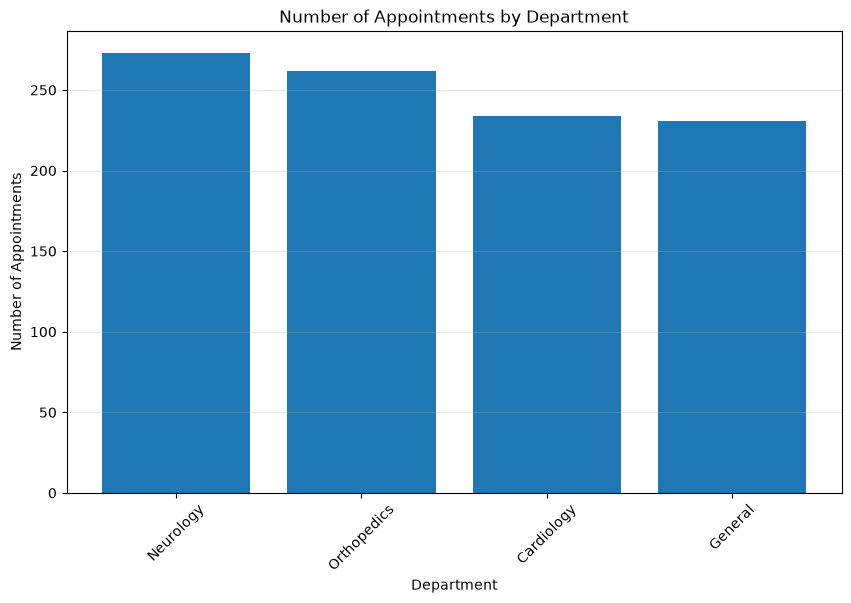

In [15]:
plt.figure(figsize=(10, 6))

plt.bar(department_counts.index, department_counts.values)

plt.title('Number of Appointments by Department')
plt.xlabel('Department')
plt.ylabel('Number of Appointments')

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.show()

In [16]:
df['appointment_date'] = pd.to_datetime(df['appointment_date'])

In [17]:
appointments_over_time = df['appointment_date'].value_counts().sort_index()

appointments_over_time.head()

appointment_date
2025-03-26    4
2025-03-27    3
2025-03-28    3
2025-03-29    2
2025-03-30    1
Name: count, dtype: int64

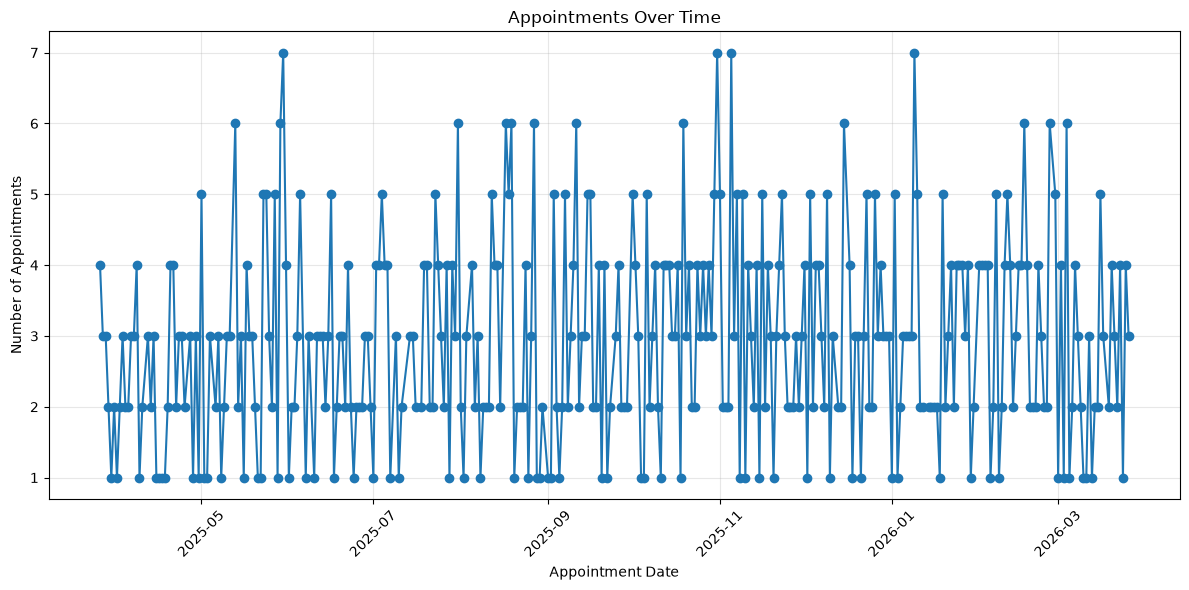

In [18]:
plt.figure(figsize=(12, 6))

plt.plot(
    appointments_over_time.index,
    appointments_over_time.values,
    marker='o'
)

plt.title('Appointments Over Time')
plt.xlabel('Appointment Date')
plt.ylabel('Number of Appointments')

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
gender_counts = df['gender'].value_counts()

gender_counts

gender
Female    527
Male      473
Name: count, dtype: int64

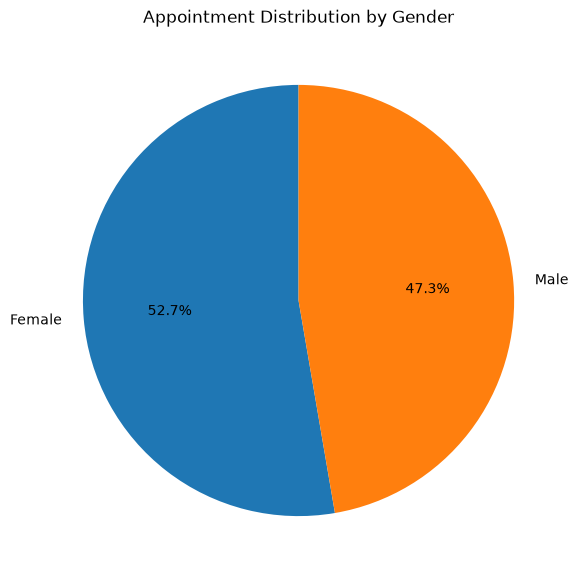

In [20]:
plt.figure(figsize=(7, 7))

plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Appointment Distribution by Gender')

plt.show()

In [21]:
df['age'].describe()

count    1000.000000
mean       53.750000
std        21.137604
min        18.000000
25%        34.000000
50%        55.000000
75%        71.000000
max        90.000000
Name: age, dtype: float64

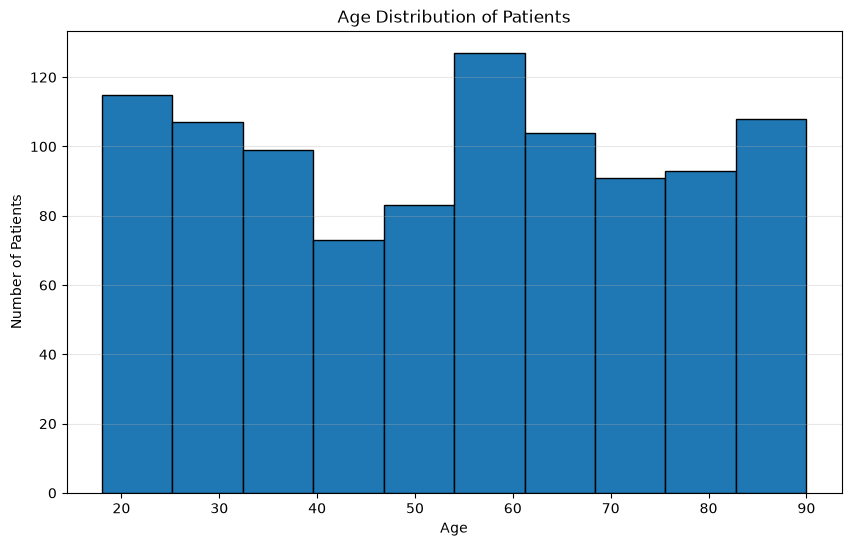

In [22]:
plt.figure(figsize=(10, 6))

plt.hist(df['age'], bins=10, edgecolor='black')

plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Number of Patients')

plt.grid(axis='y', alpha=0.3)

plt.show()

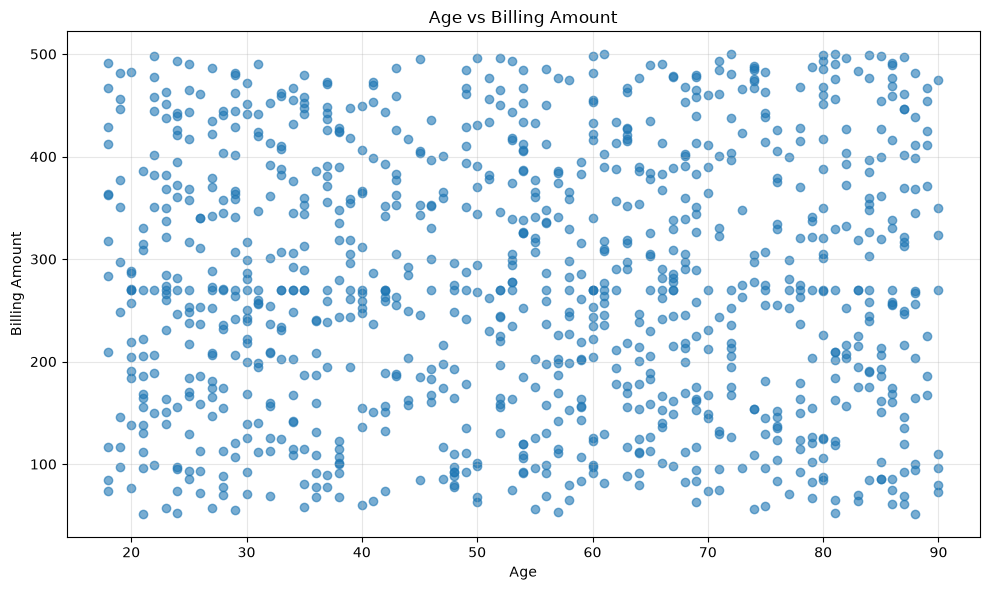

In [23]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df['age'],
    df['billing_amount'],
    alpha=0.6
)

plt.title('Age vs Billing Amount')
plt.xlabel('Age')
plt.ylabel('Billing Amount')

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

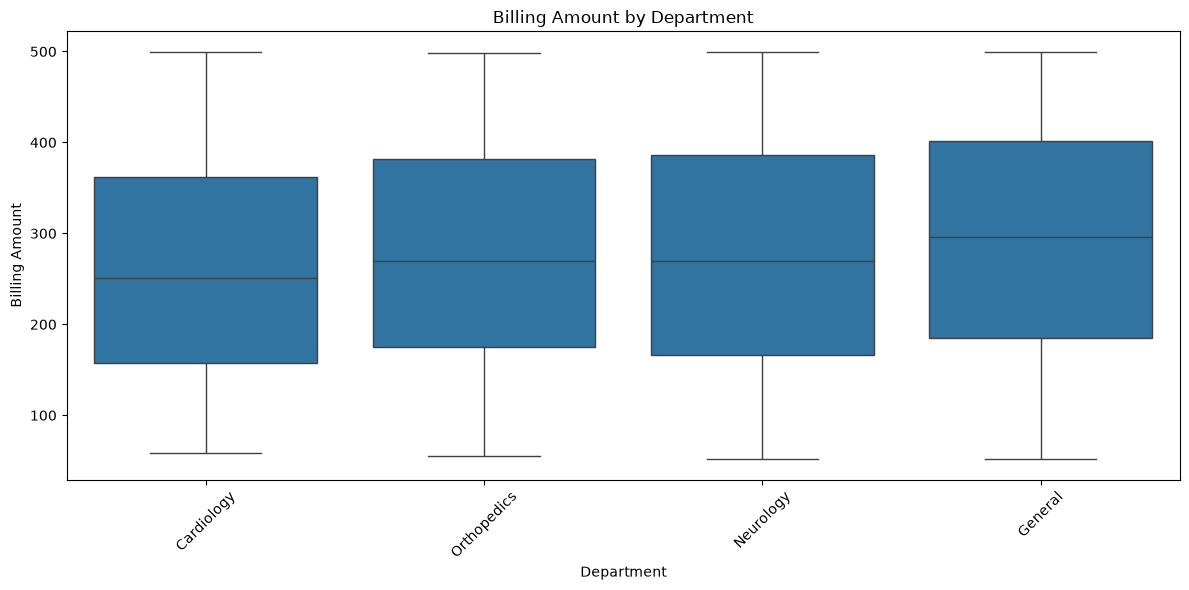

In [24]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='department',
    y='billing_amount'
)

plt.title('Billing Amount by Department')
plt.xlabel('Department')
plt.ylabel('Billing Amount')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

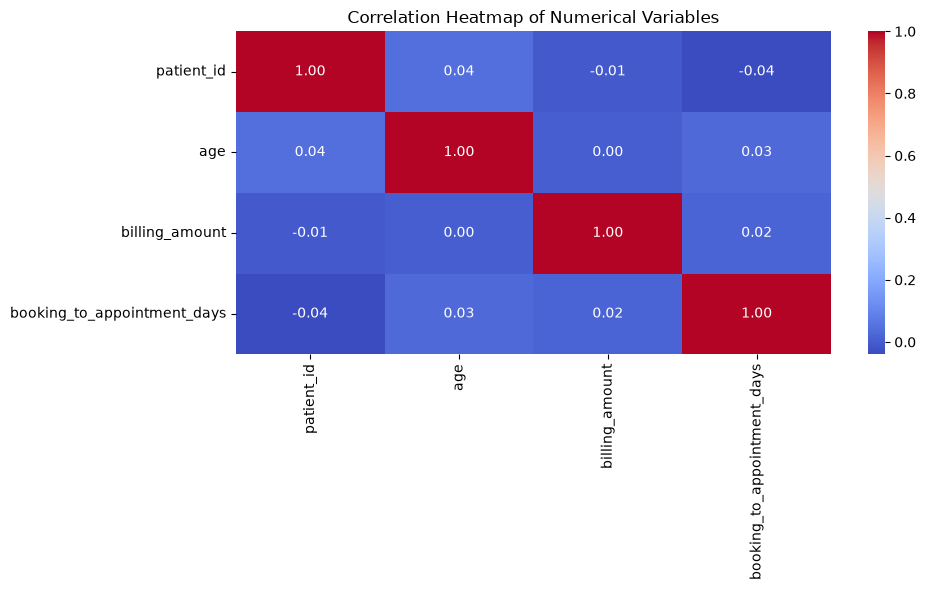

In [25]:
plt.figure(figsize=(10, 6))

numeric_columns = df.select_dtypes(include='number')

sns.heatmap(
    numeric_columns.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numerical Variables')

plt.tight_layout()
plt.show()

In [26]:
department_counts = df['department'].value_counts()

print("Department with most appointments:")
print(department_counts.idxmax())

print("Number of appointments:")
print(department_counts.max())

Department with most appointments:
Neurology
Number of appointments:
273


In [27]:
gender_counts = df['gender'].value_counts()

print("Gender distribution:")
print(gender_counts)

Gender distribution:
gender
Female    527
Male      473
Name: count, dtype: int64


In [28]:
print("Average patient age:", round(df['age'].mean(), 2))
print("Minimum patient age:", df['age'].min())
print("Maximum patient age:", df['age'].max())

Average patient age: 53.75
Minimum patient age: 18
Maximum patient age: 90


In [29]:
print("Average billing amount:", round(df['billing_amount'].mean(), 2))
print("Minimum billing amount:", df['billing_amount'].min())
print("Maximum billing amount:", df['billing_amount'].max())

Average billing amount: 275.8
Minimum billing amount: 51.38
Maximum billing amount: 499.75


In [30]:
followup_counts = df['follow_up_required'].value_counts()

print("Follow-up requirement:")
print(followup_counts)

Follow-up requirement:
follow_up_required
Yes    514
No     486
Name: count, dtype: int64


In [31]:
print(
    "Average booking-to-appointment days:",
    round(df['booking_to_appointment_days'].mean(), 2)
)

print(
    "Maximum booking-to-appointment days:",
    df['booking_to_appointment_days'].max()
)

Average booking-to-appointment days: 274.56
Maximum booking-to-appointment days: 728


# Key Findings

### 1. Appointment Distribution

Neurology had the highest number of appointments, with **273 appointments**.

### 2. Patient Demographics

The average patient age was **53.75 years**, with patient ages ranging from **18 to 90 years**.

### 3. Gender Distribution

The dataset contains **527 female appointments** and **473 male appointments**. Female appointments were slightly higher than male appointments.

### 4. Billing Analysis

The average billing amount was **275.80**, with billing amounts ranging from **51.38 to 499.75**.

### 5. Follow-up Requirement

A total of **514 appointments required follow-up**, while **486 appointments did not require follow-up**.

### 6. Appointment Scheduling

The average time between booking and appointment was approximately **274.56 days**, with the maximum waiting period reaching **728 days**.

### 7. Overall Observation

The visualizations provide a clear overview of patient demographics, department-wise appointment demand, appointment trends, billing patterns, and follow-up requirements. Neurology recorded the highest appointment volume, while the patient population showed a relatively balanced gender distribution.
